In [23]:
library(tidyverse)
library(glue)
library(patchwork)

In [24]:
sessionInfo()

R version 4.2.1 (2022-06-23)
Platform: x86_64-apple-darwin13.4.0 (64-bit)
Running under: macOS Big Sur ... 10.16

Matrix products: default
BLAS/LAPACK: /Users/joonklaps/opt/anaconda3/lib/libopenblasp-r0.3.20.dylib

locale:
[1] C/C.UTF-8/C/C/C/C

attached base packages:
[1] grid      stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] gridExtra_2.3   patchwork_1.3.0 glue_1.7.0      lubridate_1.9.3
 [5] forcats_1.0.0   stringr_1.5.1   dplyr_1.1.4     purrr_1.0.2    
 [9] readr_2.1.5     tidyr_1.3.1     tibble_3.2.1    ggplot2_3.5.2  
[13] tidyverse_2.0.0

loaded via a namespace (and not attached):
 [1] pillar_1.10.2      compiler_4.2.1     RColorBrewer_1.1-3 base64enc_0.1-3   
 [5] tools_4.2.1        bit_4.0.5          digest_0.6.36      uuid_1.2-0        
 [9] timechange_0.3.0   jsonlite_1.8.8     evaluate_1.0.3     lifecycle_1.0.4   
[13] gtable_0.3.6       pkgconfig_2.0.3    rlang_1.1.4        IRdisplay_1.1     
[17] cli_3.6.3      

In [25]:
fident_window_to_digits <- function(x) {
  rng <- str_match(as.character(x), "\\[?(0?\\.\\d+),\\s*(1|0?\\.\\d+)\\]")
  lo <- as.numeric(rng[, 2])
  hi <- as.numeric(rng[, 3])
  sprintf("%02d%02d", round(lo * 100), round(hi * 100))
}

In [6]:
selected_references <- read_tsv("./data-preparation/selected-references/selected_references.tsv")%>%select(query, target, segment, fident_window)
reference_to_original <- read_tsv("./data-preparation/global-alignment/reference_global_alignment_stats.tsv")%>%
    mutate(seq2_id = gsub("^_R_", "", seq2_id),
        sample = gsub("^(LVE\\d{5})-.*", "\\1", seq2_id),
    )%>%
    left_join(selected_references, by = c("seq1_id" = "target", "sample"= "query"))

Rows: 178 Columns: 16
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (4): query, target, segment, fident_window
dbl (12): fident, alnlen, mismatch, gapopen, qstart, qend, qlen, tstart, ten...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 178 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (2): seq1_id, seq2_id
dbl (11): alignment_length, comparable_sites, matches, mismatches, mismatch_...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [7]:
consensus_to_original <- read_tsv("./data-preparation/global-alignment/consensus_global_alignment_stats.tsv")%>%
    mutate(
        reference_distance = gsub("^(LVE\\d{5}-[RVDB0-9]{4,5})_.*", "\\1", seq1_id),
        index = gsub("^(LVE\\d{5}-[RVDB0-9]{4,5})_(.*).consensus.ivar", "\\2", seq1_id),
        segment = ifelse(alignment_length > 5000, "L", "S"),
        seq2_id = gsub("^_R_", "", seq2_id),
    )
selected_references <- read_tsv("./data-preparation/selected-references/selected_references.tsv")%>%select(query, target, segment, fident_window)
reference_to_original <- read_tsv("./data-preparation/global-alignment/reference_global_alignment_stats.tsv")%>%
    mutate(seq2_id = gsub("^_R_", "", seq2_id),
        sample = gsub("^(LVE\\d{5})-.*", "\\1", seq2_id),
    )%>%
    left_join(selected_references, by = c("seq1_id" = "target", "sample"= "query"))%>%
    mutate(reference_distance = glue::glue("{sample}-{fident_window_to_digits(fident_window)}"))

contig_table <- read_tsv("viralmetagenome-out/combined/contigs_overview.tsv")

Rows: 265 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (2): seq1_id, seq2_id
dbl (11): alignment_length, comparable_sites, matches, mismatches, mismatch_...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 178 Columns: 16
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (4): query, target, segment, fident_window
dbl (12): fident, alnlen, mismatch, gapopen, qstart, qend, qlen, tstart, ten...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 178 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (2): seq1_id, seq2_id
dbl (11): alignment_length, comparable_sites, matches, mismatches, mism

In [8]:
consensus_vs_reference<-
    left_join(
        merge(consensus_to_original, contig_table, by=c("index","reference_distance")),
        reference_to_original,
        by = c("seq2_id" = "seq2_id", "reference_distance" = "reference_distance"),
        suffix = c("_consensus", "_reference")
    )



In [9]:
consensus_vs_reference <-
    left_join(
        merge(consensus_to_original, contig_table, by=c("index","reference_distance")),
        reference_to_original,
        by = c("seq2_id" = "seq2_id", "reference_distance" = "reference_distance", "sample" = "sample"),
        suffix = c("", "_reference")
    )%>%
    mutate(
        is_external_reference_scaffold = ifelse(grepl("NODE|k\\d{3}", `(cluster) centroid`), FALSE, TRUE),
        is_RVDB_reference = ifelse(grepl("RVDB", reference_distance), TRUE, FALSE),
        fident = matches_reference/alignment_length_reference,
    )%>%
    filter(sample!="LVE00223") # Sample with multiple complete segments depending on reference used
head(consensus_vs_reference)

,index,reference_distance,seq1_id,seq2_id,alignment_length,comparable_sites,matches,mismatches,mismatch_rate,seq1_length,⋯,seq2_length_reference,seq1_gaps_reference,seq2_gaps_reference,seq1_Ns_reference,seq2_Ns_reference,segment_reference,fident_window,is_external_reference_scaffold,is_RVDB_reference,fident
,<chr>,<glue>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<lgl>,<lgl>,<dbl>
1,LVE00045_cl0_it2,LVE00045-6466,LVE00045-6466_LVE00045_cl0_it2.consensus_ivar,LVE00045-RVDB_LVE00045_cl1_it2.consensus_ivar,3443,1822,1798,33,0.018112,1891,⋯,NA,NA,NA,NA,NA,NA,NA,FALSE,FALSE,NA
2,LVE00045_cl0_it2,LVE00045-6668,LVE00045-6668_LVE00045_cl0_it2.consensus_ivar,LVE00045-RVDB_LVE00045_cl1_it2.consensus_ivar,3443,1822,1798,33,0.018112,1891,⋯,NA,NA,NA,NA,NA,NA,NA,FALSE,FALSE,NA
3,LVE00045_cl0_it2,LVE00045-6870,LVE00045-6870_LVE00045_cl0_it2.consensus_ivar,LVE00045-RVDB_LVE00045_cl1_it2.consensus_ivar,3443,1822,1798,33,0.018112,1891,⋯,3407,26,21,385,58,S,"(0.68,0.7]",FALSE,FALSE,0.6662777
4,LVE00045_cl0_it2,LVE00045-7274,LVE00045-7274_LVE00045_cl0_it2.consensus_ivar,LVE00045-RVDB_LVE00045_cl1_it2.consensus_ivar,3443,1822,1798,33,0.018112,1891,⋯,3407,112,8,186,58,S,"(0.72,0.74]",FALSE,FALSE,0.7057101
5,LVE00045_cl0_it2,LVE00045-7476,LVE00045-7476_LVE00045_cl0_it2.consensus_ivar,LVE00045-RVDB_LVE00045_cl0_it2.consensus_ivar,7264,7240,5903,1,0.000138,7263,⋯,7242,242,264,522,845,L,"(0.74,0.76]",TRUE,FALSE,0.7407407
6,LVE00045_cl0_it2,LVE00045-7678,LVE00045-7678_LVE00045_cl0_it2.consensus_ivar,LVE00045-RVDB_LVE00045_cl0_it2.consensus_ivar,7242,7164,6043,0,0.000000,7164,⋯,7242,78,0,239,845,L,"(0.76,0.78]",TRUE,FALSE,0.7912179


In [11]:
dim(consensus_vs_reference)

[1] 233 204

In [12]:
# Sampels for which we didn't have a reference in the setup
consensus_vs_reference%>%filter(is.na(segment_reference))%>%dim()

[1]  77 204

Warning message:
“Removed 124 rows containing missing values or values outside the scale range
(`geom_point()`).”


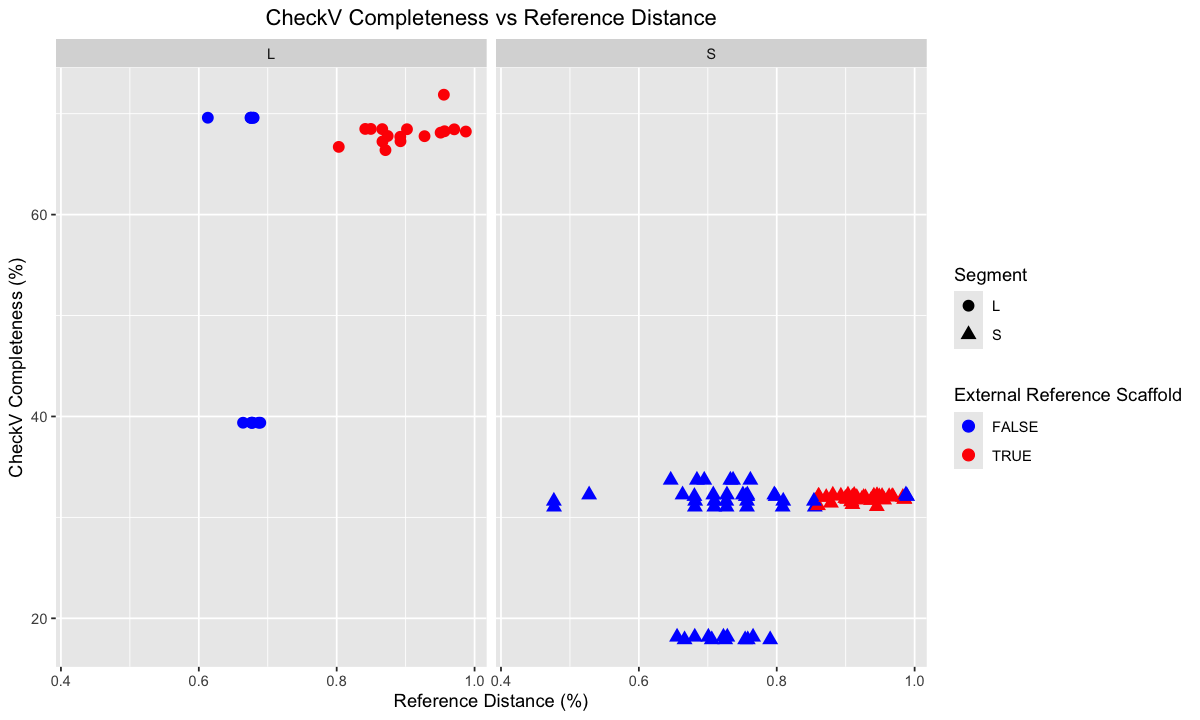

In [13]:
options(repr.plot.width=10, repr.plot.height=6)
ggplot(consensus_vs_reference, aes(x=fident, y=`(checkv) completeness`, color=is_external_reference_scaffold, shape=segment)) +
    geom_point(size=3) +
    facet_wrap(~segment) +
    labs(x="Reference Distance (%)", y="CheckV Completeness (%)", color="External Reference Scaffold", shape="Segment") +
    scale_color_manual(values=c("TRUE"="red", "FALSE"="blue")) +
    ggtitle("CheckV Completeness vs Reference Distance") +
    theme(plot.title = element_text(hjust = 0.5))

In [14]:
valid_consensus <- unique(consensus_vs_reference%>%filter(grepl("RVDB", reference_distance))%>%pull(index))
coverage_files <- list.files("viralmetagenome-out/coverages/", pattern="*.tsv", full.names=TRUE)
read_tsv2 <- function(file, filename) {
    data <- read_tsv(file)
    data <- data %>%
        mutate(
            file = basename(file)
        )
    return(data)
}
coverage_data <- do.call(rbind, lapply(coverage_files, read_tsv2))
coverage_data <- coverage_data %>%
    mutate(
        index = gsub("^(LVE\\d{5}.+).vcf.tsv", "\\1", file),
        sample = gsub("^(LVE\\d{5}).*", "\\1", index),
        reference_distance = glue("{sample}-RVDB")
    )%>%
    filter(index %in% valid_consensus) %>% # Sample with multiple complete segments depending on reference used
    merge(contig_table%>%select(index, reference_distance, `(annotation) segment`), by=c("index","reference_distance"))%>%
    mutate(segment = glue("{`(annotation) segment`} Segment"))%>%
    mutate(depth= A + C + G + T)%>%
    group_by(index, reference_distance, segment, sample) %>%
    complete(POS = 1:max(POS), fill = list(depth = 0)) %>%
    ungroup()

Rows: 6399 Columns: 11
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): REF, Consensus
dbl (9): POS, A, C, G, T, Insertions, Deletions, Entropy, Weighted Entropy

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 3365 Columns: 11
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): REF, Consensus
dbl (9): POS, A, C, G, T, Insertions, Deletions, Entropy, Weighted Entropy

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 1428 Columns: 11
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): REF, Consensus
dbl (9): POS, A, C, G, T, Insertions, Deletions, Entropy, Weighted Entropy

ℹ Use `spec()` to retrieve the f

`summarise()` has grouped output by 'index', 'reference_distance', 'segment'.
You can override using the `.groups` argument.
Warning message:
“Removed 83 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 112 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 83 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 112 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 83 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 112 rows containing missing values or values outside the scale range
(`geom_line()`).”


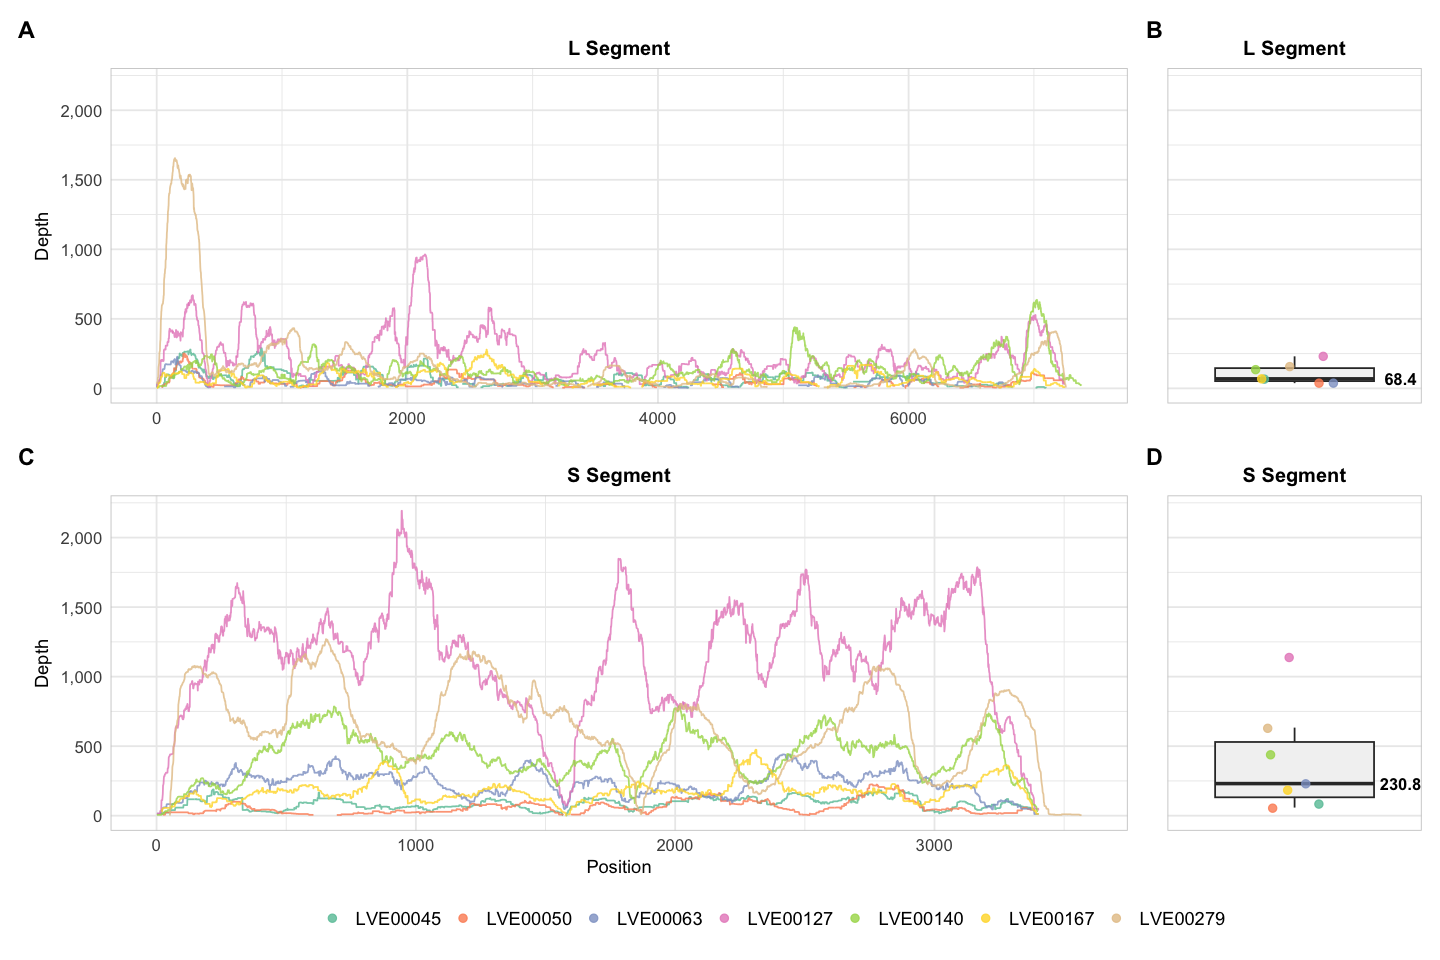

In [26]:
options(repr.plot.width=12, repr.plot.height=8)

theme_coverage <- theme_minimal(base_size = 11) +
    theme(
        plot.title = element_text(face = "bold", hjust = 0.5, size = 12),
        axis.title = element_text(size = 11),
        axis.text = element_text(size = 10),
        legend.text = element_text(size = 11),
        panel.border = element_rect(colour = "grey80", fill = NA),
        legend.position = "bottom"
    )

mean_cov_data <- coverage_data %>%
    group_by(index, reference_distance, segment, sample) %>%
    summarise(mean_depth = mean(depth, na.rm = TRUE)) %>%
    ungroup()

# Calculate median of the mean depths for labeling
segment_medians <- mean_cov_data %>%
    group_by(segment) %>%
    summarise(median_depth = median(mean_depth)) %>%
    mutate(label = round(median_depth, 1))

# Determine common Y-axis limits
max_depth <- max(c(coverage_data$depth, mean_cov_data$mean_depth), na.rm = TRUE)
y_limits <- c(1, max_depth + 1)

# L Segment Plots
p_line_L <- ggplot(filter(coverage_data, segment == "L Segment"), aes(x = POS, y = depth , color = sample)) +
    geom_line(alpha = 0.8) +
    scale_y_continuous(labels = scales::comma, name = expression("Depth"), limits = y_limits) +
    # scale_y_log10(labels = scales::comma, name = expression("Depth (log"[10]*")"), limits = y_limits) +
    scale_color_brewer(palette = "Set2") +
    guides(color = "none") +
    labs(title = "L Segment", x = NULL, color = "Sample") +
    theme_coverage

p_box_L <- ggplot(filter(mean_cov_data, segment == "L Segment"), aes(x = "", y = mean_depth)) +
    geom_boxplot(fill = "grey95", outlier.shape = NA) +
    geom_jitter(aes(color = sample), width = 0.2, size = 2, alpha = 0.8) +
    geom_text(data = filter(segment_medians, segment == "L Segment"), aes(x = "", y = median_depth, label = label),
              nudge_x = 0.5, fontface = "bold", size = 3.5) +
    # scale_y_log10(labels = scales::comma, name = NULL, limits = y_limits) +
    scale_y_continuous(labels = scales::comma, name = expression("Depth"), limits = y_limits) +
    scale_color_brewer(palette = "Set2") +
    guides(color = "none") +
    labs(title = "L Segment", x = NULL, color = "Sample") +
    theme_coverage +
    theme(
        axis.text.y = element_blank(),
        axis.ticks.y = element_blank(),
        axis.title.y = element_blank(),
        axis.text.x = element_blank(),
        axis.ticks.x = element_blank(),
        panel.grid.major.x = element_blank()
    )

# S Segment Plots
p_line_S <- ggplot(filter(coverage_data, segment == "S Segment"), aes(x = POS, y = depth, color = sample)) +
    geom_line(alpha = 0.8) +
    # scale_y_log10(labels = scales::comma, name = expression("Depth (log"[10]*")"), limits = y_limits) +
    scale_y_continuous(labels = scales::comma, name = expression("Depth"), limits = y_limits) +
    scale_color_brewer(palette = "Set2") +
    guides(color = "none") +
    labs(title = "S Segment", x = "Position", color = "Sample") +
    theme_coverage

p_box_S <- ggplot(filter(mean_cov_data, segment == "S Segment"), aes(x = "", y = mean_depth)) +
    geom_boxplot(fill = "grey95", outlier.shape = NA) +
    geom_jitter(aes(color = sample), width = 0.2, size = 2, alpha = 0.8) +
    geom_text(data = filter(segment_medians, segment == "S Segment"), aes(x = "", y = median_depth, label = label),
              nudge_x = 0.5, fontface = "bold", size = 3.5) +
    # scale_y_log10(labels = scales::comma, name = NULL, limits = y_limits) +
    scale_y_continuous(labels = scales::comma, name = expression("Depth"), limits = y_limits) +
    scale_color_brewer(palette = "Set2") +
    guides(color = guide_legend(nrow = 1)) +
    labs(title = "S Segment", x = NULL, color = "") +
    theme_coverage +
    theme(
        axis.text.y = element_blank(),
        axis.ticks.y = element_blank(),
        axis.title.y = element_blank(),
        axis.text.x = element_blank(),
        axis.ticks.x = element_blank(),
        panel.grid.major.x = element_blank()
    )

# Combine plots using patchwork
p <- p_line_L  + p_box_L + p_line_S + p_box_S  +
    plot_layout(ncol = 2, widths = c(4, 1), guides = "collect") +
    plot_annotation(tag_levels = 'A') &
    theme(legend.position = "bottom", plot.tag = element_text(face = "bold", size = 14))

p
ggsave("./images/coverages.png", plot = p, width = 12, height = 8, dpi = 300)
ggsave("./../../../Fig/supplfig3.png", plot = p, width = 12, height = 8, dpi = 300)

Warning message:
“Removed 7 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 9 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 9 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 7 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 7 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 10 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 10 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 1 

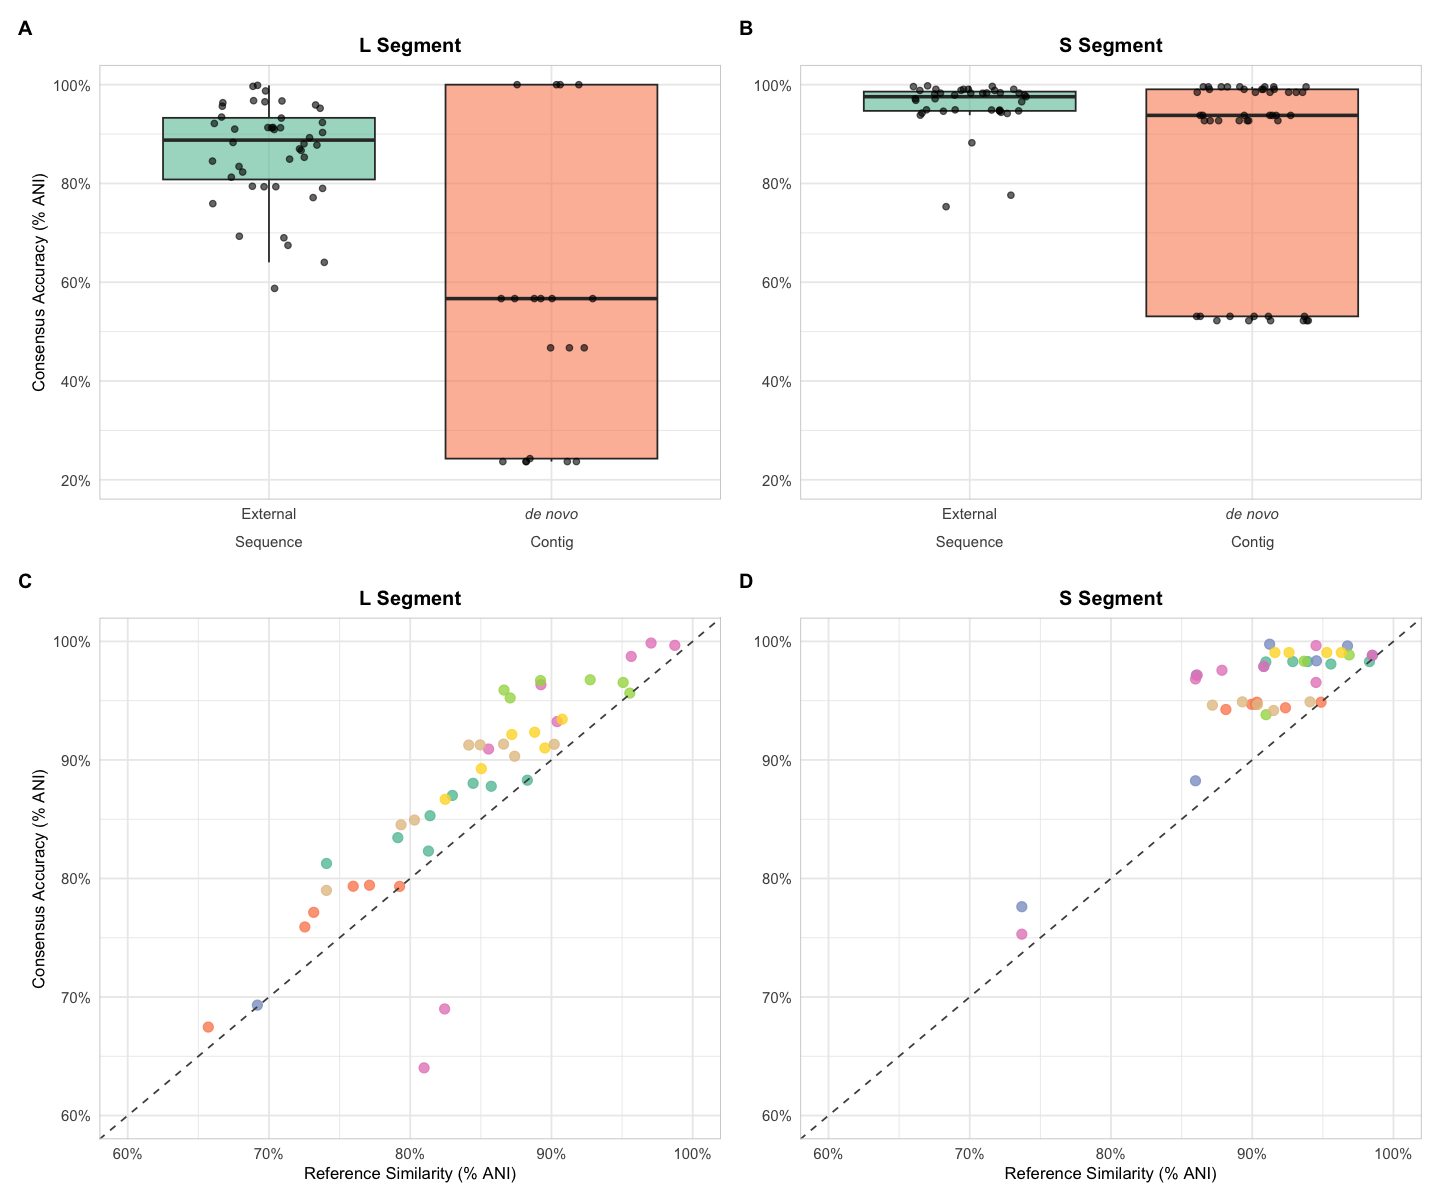

In [39]:
options(repr.plot.width=12, repr.plot.height=10)

# Prepare data
plot_consensus <- consensus_vs_reference %>%
    mutate(
        scaffold_type = if_else(is_external_reference_scaffold, "GenBank Sequence", "denovo Contig"),
        scaffold_type = factor(scaffold_type, levels = c("GenBank Sequence", "denovo Contig")),
        segment = paste(segment, "Segment")
    ) %>%
    tidyr::drop_na(fident, matches, alignment_length)

# Define themes with smaller base size
theme_box <- theme_minimal(base_size = 11) +
    theme(
        legend.position = "none",
        plot.title = element_text(face = "bold", hjust = 0.5, size = 12),
        axis.title = element_text(size = 10),
        axis.text = element_text(size = 9),
        panel.border = element_rect(colour = "grey80", fill = NA)
    )

theme_scatter <- theme_minimal(base_size = 11) +
    theme(
        legend.position = "none",
        plot.title = element_text(face = "bold", hjust = 0.5, size = 12),
        axis.title = element_text(size = 10),
        axis.text = element_text(size = 9),
        panel.border = element_rect(colour = "grey80", fill = NA)
    )

# Plot A: L Segment Boxplot
pA <- ggplot(filter(plot_consensus, segment == "L Segment"),
             aes(x = scaffold_type, y = matches / alignment_length, fill = scaffold_type)) +
    geom_boxplot(alpha = 0.6, outlier.shape = NA) +
    geom_jitter(width = 0.2, size = 1.5, alpha = 0.6) +
    scale_fill_manual(values = c("GenBank Sequence" = "#66c2a5", "denovo Contig" = "#fc8d62")) +
    scale_y_continuous(labels = scales::percent_format(accuracy = 1), limits = c(0.2, 1)) +
    scale_x_discrete(labels = c(
        "GenBank Sequence" = expression(atop("External", "Sequence")),
        "denovo Contig" = expression(atop(italic("de novo"), "Contig"))
    )) +
    labs(title = "L Segment", x = NULL, y = "Consensus Accuracy (% ANI)") +
    theme_box

# Plot B: S Segment Boxplot
pB <- ggplot(filter(plot_consensus, segment == "S Segment"),
             aes(x = scaffold_type, y = matches / alignment_length, fill = scaffold_type)) +
    geom_boxplot(alpha = 0.6, outlier.shape = NA) +
    geom_jitter(width = 0.2, size = 1.5, alpha = 0.6) +
    scale_fill_manual(values = c("GenBank Sequence" = "#66c2a5", "denovo Contig" = "#fc8d62")) +
    scale_y_continuous(labels = scales::percent_format(accuracy = 1), limits = c(0.2, 1)) +
    scale_x_discrete(labels = c(
        "GenBank Sequence" = expression(atop("External", "Sequence")),
        "denovo Contig" = expression(atop(italic("de novo"), "Contig"))
    )) +
    labs(title = "S Segment", x = NULL, y = NULL) +
    theme_box

# Plot C: L Segment Scatter
pC <- ggplot(filter(plot_consensus, segment == "L Segment", scaffold_type == "GenBank Sequence"),
             aes(x = fident, y = matches / alignment_length, color = sample)) +
    geom_point(size = 2.5, alpha = 0.8) +
    geom_abline(slope = 1, intercept = 0, color = "grey30", linetype = "dashed", linewidth = 0.5) +
    scale_color_brewer(palette = "Set2") +
    scale_x_continuous(labels = scales::percent_format(accuracy = 1), limits = c(0.6, 1)) +
    scale_y_continuous(labels = scales::percent_format(accuracy = 1), limits = c(0.6, 1)) +
    labs(title = "L Segment", x = "Reference Similarity (% ANI)", y = "Consensus Accuracy (% ANI)") +
    theme_scatter

# Plot D: S Segment Scatter
pD <- ggplot(filter(plot_consensus, segment == "S Segment", scaffold_type == "GenBank Sequence"),
             aes(x = fident, y = matches / alignment_length, color = sample)) +
    geom_point(size = 2.5, alpha = 0.8) +
    geom_abline(slope = 1, intercept = 0, color = "grey30", linetype = "dashed", linewidth = 0.5) +
    scale_color_brewer(palette = "Set2") +
    scale_x_continuous(labels = scales::percent_format(accuracy = 1), limits = c(0.6, 1)) +
    scale_y_continuous(labels = scales::percent_format(accuracy = 1), limits = c(0.6, 1)) +
    labs(title = "S Segment", x = "Reference Similarity (% ANI)", y = NULL) +
    theme_scatter

# Combine using patchwork with adjusted heights
p <- ((pA | pB) / (pC | pD)) +
        plot_layout(heights = c(1, 1.2)) +
        plot_annotation(tag_levels = 'A') &
        theme(plot.tag = element_text(face = "bold", size = 12))

p
ggsave("./images/fig2.png", p, width = 10, height = 6, dpi = 300)
ggsave("../../../Fig/fig2.png", p, width = 10, height = 6, dpi = 300)

Warning message:
“Removed 77 rows containing missing values or values outside the scale range
(`geom_point()`).”


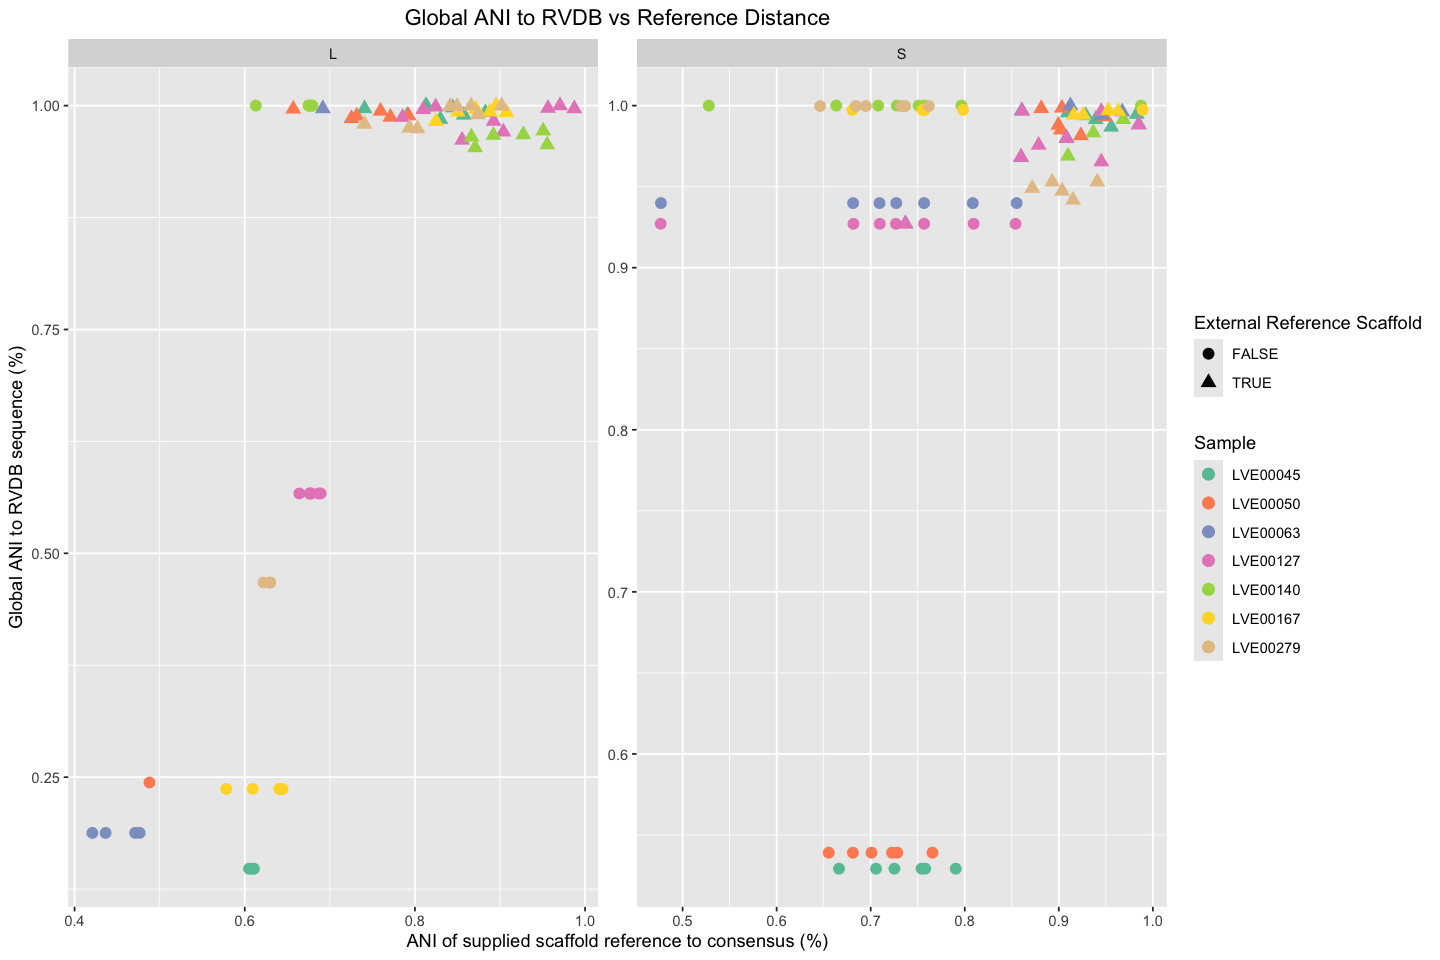

In [ ]:
ggplot(consensus_vs_reference, aes(x=fident, y=comparable_sites/alignment_length, color=sample, shape=is_external_reference_scaffold)) +
    geom_point(size=3) +
    facet_wrap(~segment, scales = "free") +
    labs(x="ANI of supplied scaffold reference to consensus (%)", y="Global ANI to RVDB sequence (%)", color="Sample", shape="External Reference Scaffold") +
    scale_color_brewer(palette = "Set2") +
    ggtitle("Global ANI to RVDB vs Reference Distance") +
    theme(plot.title = element_text(hjust = 0.5))

Warning message:
“Removed 77 rows containing missing values or values outside the scale range
(`geom_point()`).”


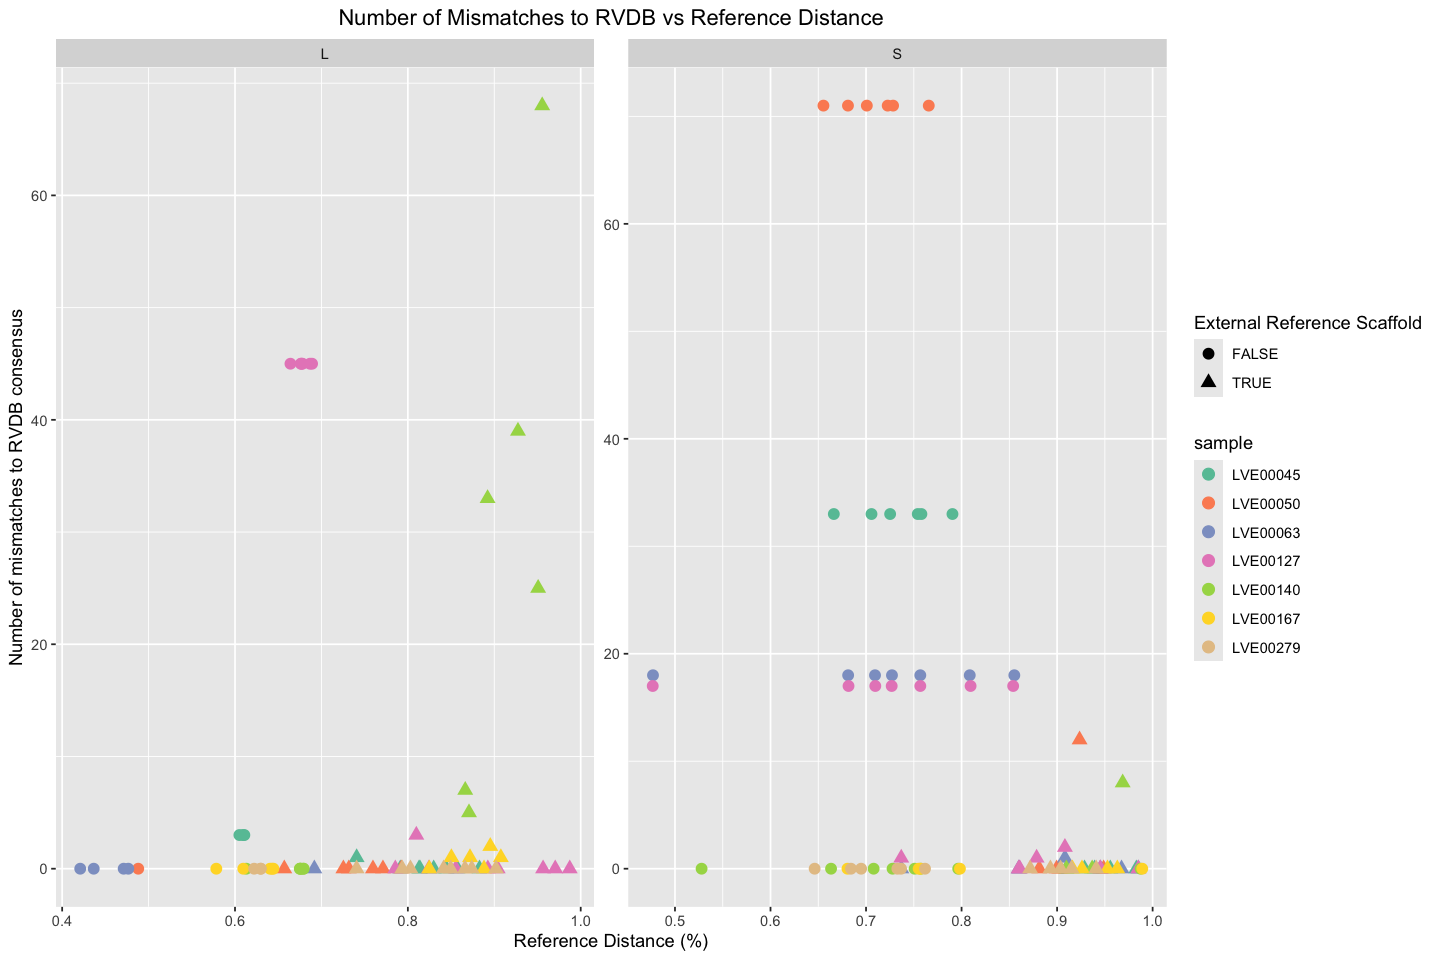

In [90]:
ggplot(consensus_vs_reference, aes(x=fident, y=mismatches,  color=sample, shape=is_external_reference_scaffold)) +
    geom_point(size=3) +
    facet_wrap(~segment, scales = "free") +
    labs(x="Reference Distance (%)", y="Number of mismatches to RVDB consensus", color="sample", shape="External Reference Scaffold") +
    scale_color_brewer(palette = "Set2") +
    ggtitle("Number of Mismatches to RVDB vs Reference Distance") +
    theme(plot.title = element_text(hjust = 0.5))

These mismatches, are occuring due to poorly aligned end regions of the sequences, or due to consensus end regions.
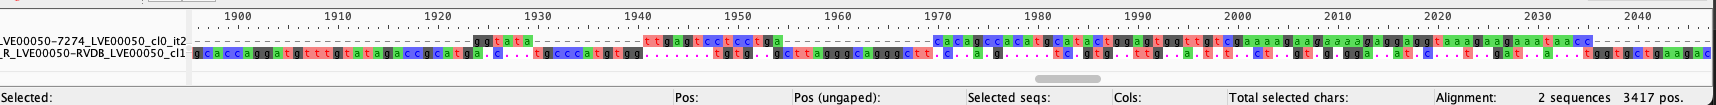
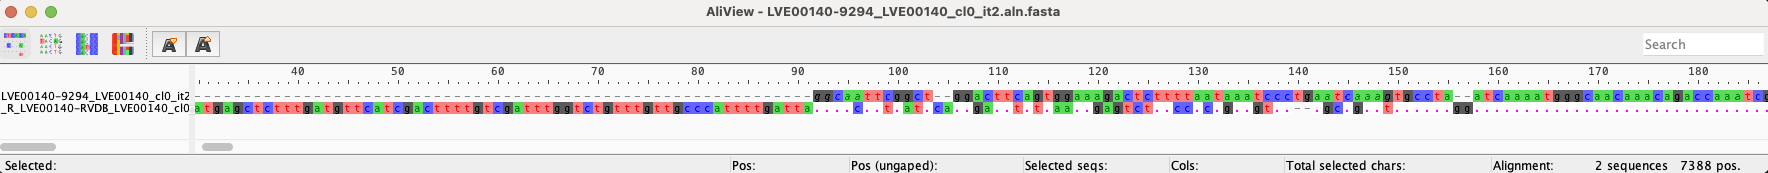


In [91]:
consensus_vs_reference%>%arrange(desc(mismatches))%>%select(mismatches, everything())%>%
    filter(seq1_length > 0.7 * alignment_length)%>%head()

,mismatches,index,reference_distance,seq1_id,seq2_id,alignment_length,comparable_sites,matches,mismatch_rate,seq1_length,⋯,seq2_length_reference,seq1_gaps_reference,seq2_gaps_reference,seq1_Ns_reference,seq2_Ns_reference,segment_reference,fident_window,is_external_reference_scaffold,is_RVDB_reference,fident
,<dbl>,<chr>,<glue>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<lgl>,<lgl>,<dbl>
1,68,LVE00140_cl0_it2,LVE00140-98100,LVE00140-98100_LVE00140_cl0_it2.consensus_ivar,LVE00140-RVDB_LVE00140_cl0_it2.consensus_ivar,7633,7300,7300,0.009315,7621,⋯,7380,188,5,96,0,L,"(0.98,1]",TRUE,FALSE,0.9554502
2,39,LVE00140_cl0_it2,LVE00140-9496,LVE00140-9496_LVE00140_cl0_it2.consensus_ivar,LVE00140-RVDB_LVE00140_cl0_it2.consensus_ivar,7383,7144,7144,0.005459,7186,⋯,7380,198,4,86,0,L,"(0.94,0.96]",TRUE,FALSE,0.9274106
3,33,LVE00140_cl0_it2,LVE00140-9294,LVE00140-9294_LVE00140_cl0_it2.consensus_ivar,LVE00140-RVDB_LVE00140_cl0_it2.consensus_ivar,7385,7141,7141,0.004621,7179,⋯,7380,207,7,339,0,L,"(0.92,0.94]",TRUE,FALSE,0.8922431
4,25,LVE00140_cl0_it2,LVE00140-9698,LVE00140-9698_LVE00140_cl0_it2.consensus_ivar,LVE00140-RVDB_LVE00140_cl0_it2.consensus_ivar,7393,7185,7137,0.003479,7223,⋯,7380,167,11,0,0,L,"(0.96,0.98]",TRUE,FALSE,0.9507509
5,18,LVE00063_cl0_it2,LVE00063-6668,LVE00063-6668_LVE00063_cl0_it2.consensus_ivar,LVE00063-RVDB_LVE00063_cl1_it2.consensus_ivar,3442,3235,3228,0.005564,3286,⋯,NA,NA,NA,NA,NA,NA,NA,FALSE,FALSE,NA
6,18,LVE00063_cl0_it2,LVE00063-6870,LVE00063-6870_LVE00063_cl0_it2.consensus_ivar,LVE00063-RVDB_LVE00063_cl1_it2.consensus_ivar,3442,3235,3228,0.005564,3286,⋯,3409,24,17,385,8,S,"(0.68,0.7]",FALSE,FALSE,0.6812609


Warning message:
“Removed 77 rows containing missing values or values outside the scale range
(`geom_point()`).”


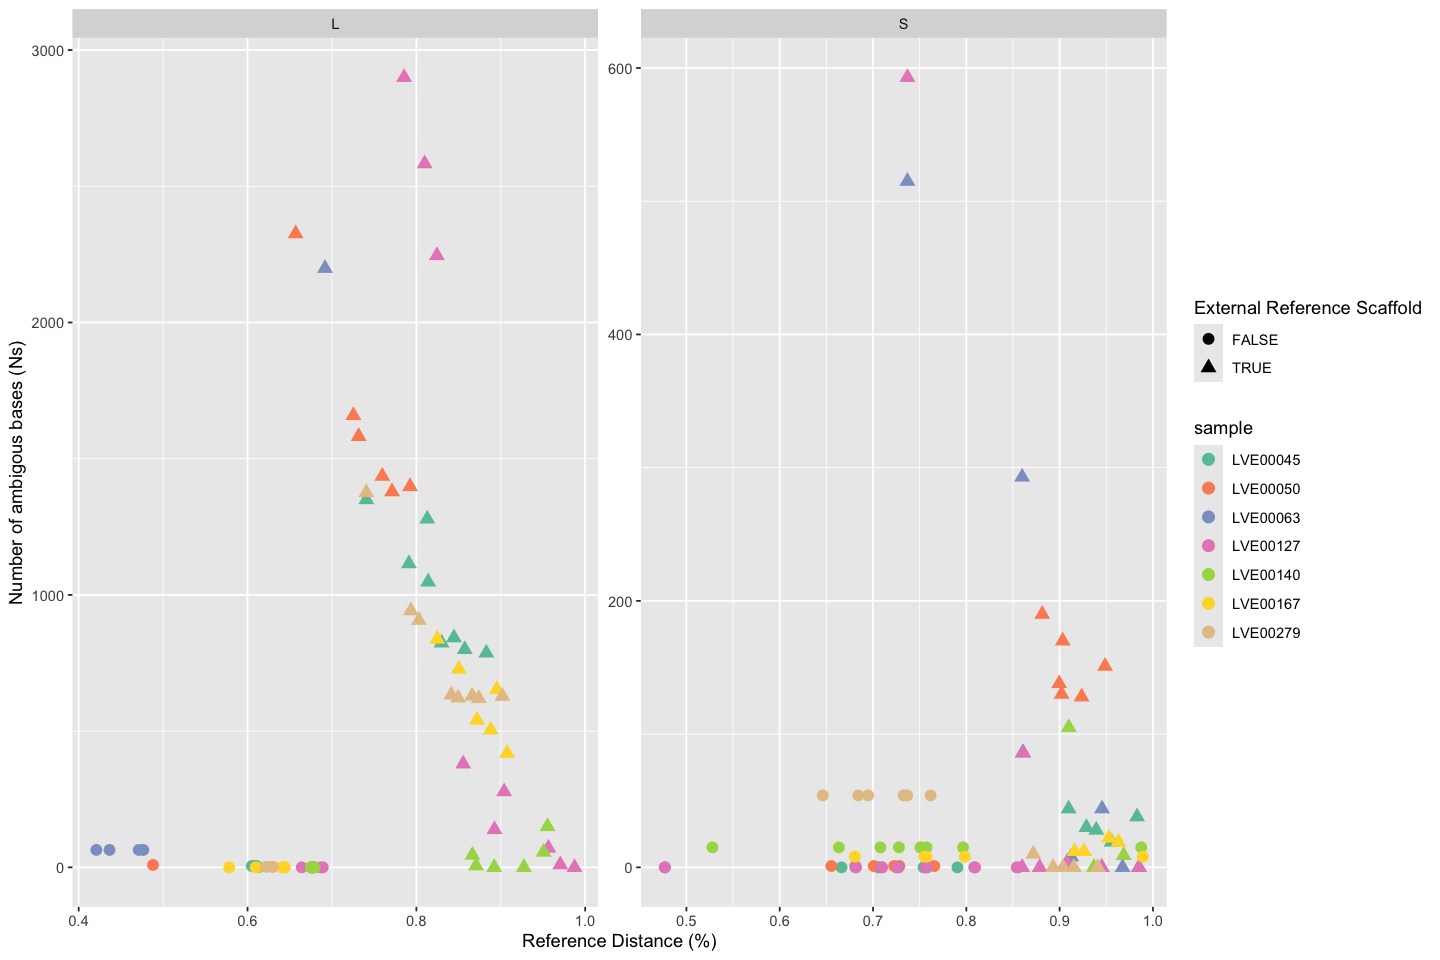

In [92]:
ggplot(consensus_vs_reference, aes(x=fident, y=seq1_Ns, color=sample, shape=is_external_reference_scaffold)) +
    geom_point(size=3) +
    facet_wrap(~segment, scales = "free") +
    labs(x="Reference Distance (%)", y="Number of ambigous bases (Ns)", color="sample", shape="External Reference Scaffold") +
    scale_color_brewer(palette = "Set2") +
    theme(plot.title = element_text(hjust = 0.5))